# โครงการวิเคราะห์ข้อมูลมาตรวิทยาด้วย Data Science และ Machine Learning

ยินดีต้อนรับสู่สมุดบันทึก (Jupyter Notebook) เล่มนี้! คู่มือฉบับนี้ถูกออกแบบขึ้นมาเพื่อให้ **มือใหม่ (Beginner)** สามารถทำความเข้าใจกระบวนการทางวิทยาศาสตร์ข้อมูล (Data Science Pipeline) ทีละขั้นตอน ตั้งแต่การเปิดไฟล์ข้อมูลไปจนถึงการเทรนโมเดลปัญญาประดิษฐ์ โดยเรียนรู้ผ่าน **ข้อมูลจริง** ของการให้บริการจาก **สถาบันมาตรวิทยาแห่งชาติ (มว.)**

### หัวข้อที่เราจะศึกษาเรียนรู้ร่วมกัน:
1. **การนำเข้าข้อมูล (Import File):** การนำเข้าและโหลดข้อมูลเข้าสู่หน่วยความจำ
2. **การตรวจสอบโครงสร้างข้อมูล (Checking Data):** การสำรวจข้อมูลเบื้องต้นเพื่อประเมินความผิดปกติ
3. **การทำความสะอาดข้อมูล (Clean Data):** การตัดข้อมูลไร้ระเบียบและการแปลงข้อมูลข้อความราคาเป็นตัวเลข
4. **การวิเคราะห์ข้อมูลเชิงสำรวจ (Exploratory Data Analysis - EDA):** การทำความเข้าใจพฤติกรรมข้อมูลผ่านกราฟแบบโต้ตอบจาก `Plotly`
5. **การแปลงคุณลักษณะและการเตรียมข้อมูล (Preprocessing & Normalization):** การแปลงข้อความรายละเอียดเป็นตัวเลข (TF-IDF)
6. **การสร้างและฝึกสอนโมเดลปัญญาประดิษฐ์ (Machine Learning):** ฝึกสอนทั้งโมเดลคัดแยกประเภท (Supervised) และการจัดกลุ่มกลุ่มตลาด (Unsupervised)
7. **การประเมินและการตีความผลลัพธ์ (Results & Interpretation):** ทำความเข้าใจดัชนีชี้วัดความแม่นยำและการจัดกลุ่มคำสำคัญ

--- 
## 1. การนำเข้าข้อมูล (Import File)

ในเบื้องต้น เราต้องนำไลบรารีที่จำเป็นเข้ามาใช้งานก่อน:
*   `pandas` (pd): เป็นเครื่องมือสำคัญในการแปลงไฟล์ข้อมูล (เช่น CSV, Excel) ให้อยู่ในโครงสร้างตาราง เรียกว่า DataFrame
*   `numpy` (np): ใช้สำหรับการคำนวณทางคณิตศาสตร์ความแม่นยำสูงและการจัดการค่าว่างเปล่า
*   `plotly.express` (px): ใช้สำหรับการทำข้อมูลให้เห็นภาพในรูปแบบกราฟแบบโต้ตอบ (Interactive Graph) ที่ผู้ใช้สามารถเลื่อนเมาส์ไปดูค่าหรือซูมได้

In [1]:
import pandas as pd
import numpy as np
import plotly.express as px
import plotly.io as pio

# กำหนด renderer สำหรับ VS Code: 'notebook' ฝัง HTML ตรงใน cell output
# (อย่าใช้ 'iframe' ใน VS Code เพราะ CSP จะบล็อก local file path)
pio.renderers.default = 'png'

# โหลดชุดข้อมูลการสอบเทียบจริง (Real NIMT calibration pricelist dataset)
# ใช้การเข้ารหัส utf-8-sig เพื่อความปลอดภัยกับฟอนต์ภาษาไทยเมื่อเปิดบนระบบต่างๆ
df = pd.read_csv("real_nimt_machine_learning.csv", encoding="utf-8-sig")
print("นำเข้าไฟล์ข้อมูลเรียบร้อยแล้ว!")

นำเข้าไฟล์ข้อมูลเรียบร้อยแล้ว!


--- 
## 2. การตรวจสอบข้อมูลเบื้องต้น (Checking Data)

**ทำไมขั้นตอนนี้ถึงสำคัญ:** 
ก่อนที่เราจะสามารถนำข้อมูลไปทำอะไรก็ตาม เราจำเป็นต้องตอบคำถามพื้นฐานเหล่านี้ให้ได้ก่อนเพื่อป้องกันข้อผิดพลาดทีหลัง:
1.  ข้อมูลมีจำนวนกี่รายการ (Shape) และคอลัมน์ใดเกี่ยวข้องบ้าง?
2.  ข้อมูลแต่ละคอลัมน์ถูกเก็บในรูปแบบที่เหมาะสมหรือไม่? (เช่น ข้อมูลราคาควรเป็นตัวเลข ไม่ใช่ข้อความ)
3.  มีข้อมูลที่ว่างเปล่า (Null / Missing values) หรือไม่? ถ้ามี.. มีจำนวนเท่าใด?

In [2]:
# ตรวจสอบขนาดของตารางข้อมูล
print(f"จำนวนแถว (Rows / รายการเครื่องมือ): {df.shape[0]}")
print(f"จำนวนคอลัมน์ (Columns): {df.shape[1]}")
print("-" * 60)

# แสดงตัวอย่างข้อมูล 5 แถวแรกเพื่อดูหน้าตาของข้อมูลในแต่ละฟิลด์
df.head(5)

จำนวนแถว (Rows / รายการเครื่องมือ): 1579
จำนวนคอลัมน์ (Columns): 12
------------------------------------------------------------


,ลำดับ (Item No.),รายละเอียดเครื่องมือ (Description),ช่วงการวัด (Range),ความสามารถการวัด (CMC / Uncertainty),ราคาค่าบริการ (Price),หมายเหตุ (Remark),รหัสบริการ (Code),ฝ่ายงานจริง (Actual Department),ราคาตัวเลข (Price Numeric),ฝ่ายงานที่ทำนาย (Predicted Department),รหัสกลุ่มคลัสเตอร์ (Cluster ID),คำสำคัญของกลุ่มคลัสเตอร์ (Cluster Keywords)
0,1.0,Iodine Stabilized He-Ne laser,633 nm,5.00E-11,"36,000/piece",Beat measurement mehod with Iodine stabilized ...,08011 - 10101,Dimensional Metrology Department,36000.0,Dimensional Metrology Department,0,"gauge, calibration, testing, machine, laser"
1,2.0,Stabilized He-Ne laser,633 nm,1.00E-09,"22,530/piece",Beat measurement mehod with Iodine stabilized ...,08011 - 10201,Dimensional Metrology Department,22530.0,Dimensional Metrology Department,0,"gauge, calibration, testing, machine, laser"
2,3.0,Stabilized He-Ne laser,500 - 1000 nm and 1560 nm,1.00E-12,"45,000/piece",Beat measurement mehod with optical comb,08011 - 10202,Dimensional Metrology Department,45000.0,Dimensional Metrology Department,0,"gauge, calibration, testing, machine, laser"
3,4.0,Stabilized He-Ne laser,532 nm,4.00E-08,"22,530/piece",Beat measurement mehod with Iodine stabilized ...,08011 - 10203,Dimensional Metrology Department,22530.0,Dimensional Metrology Department,0,"gauge, calibration, testing, machine, laser"
4,5.0,Dual frequency stabilized He-Ne laser,633 nm,1.00E-09,"25,000",Beat measurement mehod with Iodine stabilized ...,08011 - 10204,Dimensional Metrology Department,25000.0,Dimensional Metrology Department,0,"gauge, calibration, testing, machine, laser"


In [3]:
# ตรวจสอบสรุปสถิติพื้นฐาน ประเภทของตัวแปร และการใช้หน่วยความจำ
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1579 entries, 0 to 1578
Data columns (total 12 columns):
 #   Column                                       Non-Null Count  Dtype  
---  ------                                       --------------  -----  
 0   ลำดับ (Item No.)                             1060 non-null   float64
 1   รายละเอียดเครื่องมือ (Description)           1579 non-null   object 
 2   ช่วงการวัด (Range)                           1503 non-null   object 
 3   ความสามารถการวัด (CMC / Uncertainty)         1446 non-null   object 
 4   ราคาค่าบริการ (Price)                        1557 non-null   object 
 5   หมายเหตุ (Remark)                            980 non-null    object 
 6   รหัสบริการ (Code)                            1579 non-null   object 
 7   ฝ่ายงานจริง (Actual Department)              1579 non-null   object 
 8   ราคาตัวเลข (Price Numeric)                   1579 non-null   float64
 9   ฝ่ายงานที่ทำนาย (Predicted Department)       1579 non-null   object 
 10  

In [4]:
# ตรวจสอบว่าในแต่ละคอลัมน์มีค่าสูญหายหรือข้อมูลว่างเปล่า (Missing Values) หรือไม่
print("ตรวจสอบจำนวนค่าว่างในแต่ละฟิลด์ข้อมูล:")
df.isnull().sum()

ตรวจสอบจำนวนค่าว่างในแต่ละฟิลด์ข้อมูล:


ลำดับ (Item No.)                               519
รายละเอียดเครื่องมือ (Description)               0
ช่วงการวัด (Range)                              76
ความสามารถการวัด (CMC / Uncertainty)           133
ราคาค่าบริการ (Price)                           22
หมายเหตุ (Remark)                              599
รหัสบริการ (Code)                                0
ฝ่ายงานจริง (Actual Department)                  0
ราคาตัวเลข (Price Numeric)                       0
ฝ่ายงานที่ทำนาย (Predicted Department)           0
รหัสกลุ่มคลัสเตอร์ (Cluster ID)                  0
คำสำคัญของกลุ่มคลัสเตอร์ (Cluster Keywords)      0
dtype: int64

--- 
## 3. การทำความสะอาดข้อมูล (Clean Data)

**แนวคิดและเหตุผลประกอบ:**
จากการตรวจสอบข้อมูลในขั้นตอนที่แล้ว เราพบความท้าทาย 2 ประการหลักในการวิเคราะห์เชิงปริมาณ:
1.  **คอลัมน์ราคา (`ราคาค่าบริการ (Price)`):** ข้อมูลจริงมาในรูปแบบตัวอักษรปนตัวเลข เช่น `"36,000/piece"` หรือ `"22,530/point"` คอมพิวเตอร์ไม่เข้าใจว่านี่คือตัวเลขสำหรับนำไปหาค่าเฉลี่ยหรือสร้างโมเดลทำนายได้
2.  **ข้อมูลว่างเปล่า (Null / Missing Value):** บางรายการสอบเทียบไม่มีการระบุค่าราคาค่าบริการ

**แนวทางการแก้ปัญหา:**
*   เขียนสคริปต์สกัดเฉพาะตัวเลขทศนิยม (`float`) ออกจากข้อความราคาโดยใช้ Regular Expression (Regex)
*   การจัดการค่าว่างของราคา: เราจะใช้เทคนิค **Imputation** โดยการแทนค่าที่ว่างเปล่าด้วยค่ามัธยฐาน (Median) ของราคาทั้งหมด เพราะค่ามัธยฐานทนทานต่อข้อมูลที่เด้งสูงผิดปกติ (Outliers) ได้ดีกว่าค่าเฉลี่ย

In [5]:
import re

# 3.1 ตัดช่องว่างส่วนเกินหน้า-หลังของข้อความตัวอักษรเพื่อความสอดคล้องกัน
df['รายละเอียดเครื่องมือ (Description)'] = df['รายละเอียดเครื่องมือ (Description)'].str.strip()
df['ฝ่ายงานจริง (Actual Department)'] = df['ฝ่ายงานจริง (Actual Department)'].str.strip()
df['ฝ่ายงานจริง (Actual Department)'] = df['ฝ่ายงานจริง (Actual Department)'].str.replace(r'  +', ' ', regex=True)  # แก้ไขช่องว่างสองช่องในชื่อฝ่ายงาน

# 3.2 สร้างฟังก์ชันเพื่อสกัดและล้างข้อมูลราคาตัวเลข
def clean_price_value(val):
    if pd.isna(val):
        return np.nan
    # ตัดส่วนคำว่า /piece หรือ /point และเอาเครื่องหมายจุลภาคออก
    val_str = str(val).replace(',', '').split('/')[0].strip()
    try:
        return float(val_str)
    except ValueError:
        # ใช้ Regular Expression ในการจับกลุ่มตัวเลขหลักแรก
        nums = re.findall(r'\d+', val_str)
        if nums:
            return float(nums[0])
        return np.nan

# เรียกใช้ฟังก์ชันแปลงราคา
df['ราคาตัวเลข (Price Numeric)'] = df['ราคาค่าบริการ (Price)'].apply(clean_price_value)

# 3.3 แทนที่ค่าว่างของราคาตัวเลขด้วยค่ามัธยฐาน (Median)
median_val = df['ราคาตัวเลข (Price Numeric)'].median()
df['ราคาตัวเลข (Price Numeric)'] = df['ราคาตัวเลข (Price Numeric)'].fillna(median_val)

print(f"ค่ามัธยฐานของอัตราค่าบริการสอบเทียบ: {median_val:,.2f} บาท (ใช้เพื่อทดแทนช่องที่ว่างเปล่า)")
print("จำนวนค่าว่างคงเหลือในฟิลด์ราคาตัวเลข:", df['ราคาตัวเลข (Price Numeric)'].isnull().sum())

ค่ามัธยฐานของอัตราค่าบริการสอบเทียบ: 7,880.00 บาท (ใช้เพื่อทดแทนช่องที่ว่างเปล่า)
จำนวนค่าว่างคงเหลือในฟิลด์ราคาตัวเลข: 0


--- 
## 4. การวิเคราะห์ข้อมูลเชิงสำรวจ (Exploratory Data Analysis - EDA)

**แนวคิดและเหตุผลประกอบ:**
การสร้างกราฟนำเสนอข้อมูลช่วยให้เรามองเห็นรูปแบบ (Patterns) พฤติกรรม และความสัมพันธ์ของข้อมูลแบบเชิงประจักษ์:
1.  **ปริมาณงานรายฝ่ายงาน:** เพื่อดูว่าแผนกใดในสถาบันมาตรวิทยาฯ รับภาระการสอบเทียบเครื่องมือวัดมากที่สุด
2.  **การกระจายตัวของราคา (Box Plot):** ช่วยตอบโจทย์ว่าฝ่ายใดมีค่าบริการเฉลี่ยแพงที่สุด และมีเครื่องมือสอบเทียบชนิดใดที่ราคาสูงผิดปกติ (Outliers) บ้าง
3.  **สัดส่วนปริมาณงาน:** การแจกแจงเปอร์เซ็นต์ส่วนแบ่งในภาพรวม

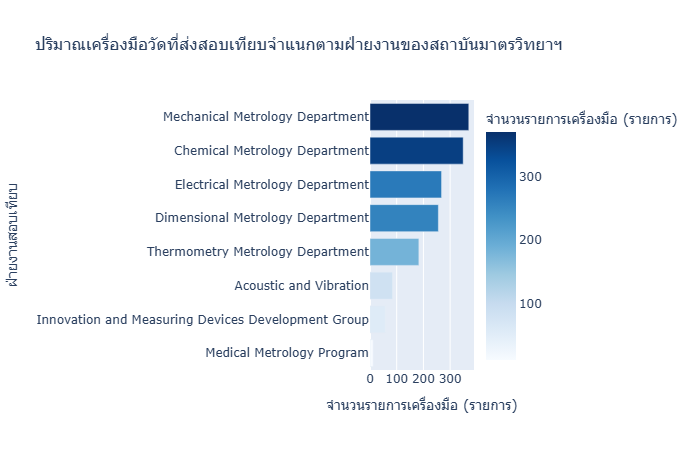

In [6]:
# 4.1 กราฟแท่งแสดงปริมาณเครื่องมือวัดจำแนกตามฝ่ายงาน (Department Volume)
dept_counts = df['ฝ่ายงานจริง (Actual Department)'].value_counts().reset_index()
dept_counts.columns = ['Department', 'Count']

fig_bar = px.bar(
    dept_counts, 
    x='Count', 
    y='Department', 
    orientation='h',
    title='ปริมาณเครื่องมือวัดที่ส่งสอบเทียบจำแนกตามฝ่ายงานของสถาบันมาตรวิทยาฯ',
    labels={'Count': 'จำนวนรายการเครื่องมือ (รายการ)', 'Department': 'ฝ่ายงานสอบเทียบ'},
    color='Count',
    color_continuous_scale='Blues'
)
fig_bar.update_layout(yaxis={'categoryorder':'total ascending'}, height=450)
fig_bar.show()

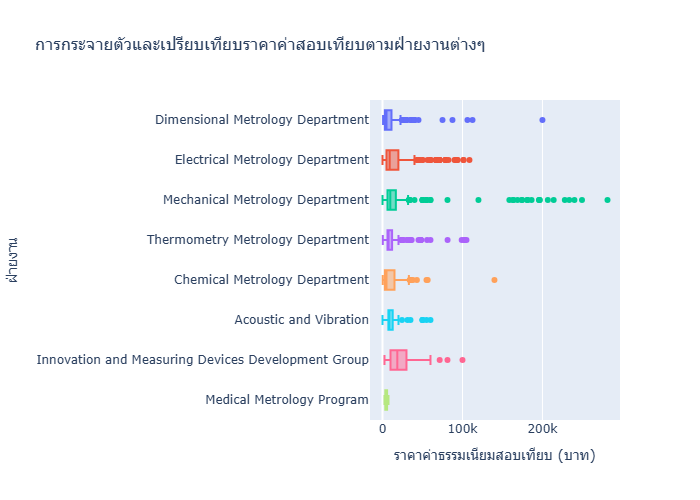

In [7]:
# 4.2 กราฟกล่อง (Box Plot) แสดงการกระจายตัวของราคาค่าธรรมเนียมของแต่ละฝ่ายงาน
# ช่วยให้เราเปรียบเทียบระดับช่วงราคาและความกว้างของราคาระหว่างฝ่ายงานได้ในทันที
fig_box = px.box(
    df, 
    x='ราคาตัวเลข (Price Numeric)', 
    y='ฝ่ายงานจริง (Actual Department)',
    title='การกระจายตัวและเปรียบเทียบราคาค่าสอบเทียบตามฝ่ายงานต่างๆ',
    labels={'ราคาตัวเลข (Price Numeric)': 'ราคาค่าธรรมเนียมสอบเทียบ (บาท)', 'ฝ่ายงานจริง (Actual Department)': 'ฝ่ายงาน'},
    color='ฝ่ายงานจริง (Actual Department)',
    points='outliers' # วาดจุดแยกสำหรับข้อมูลที่หลุดกลุ่มปกติ
)
fig_box.update_layout(showlegend=False, height=500)
fig_box.show()

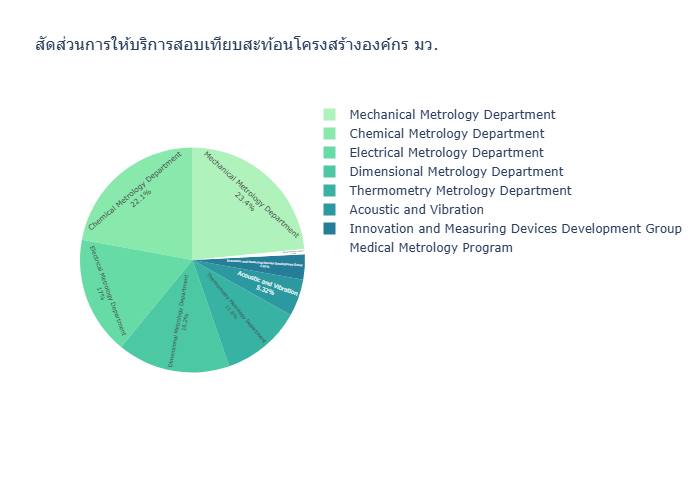

In [8]:
# 4.3 กราฟวงกลมแสดงสัดส่วนโครงสร้างบริการสอบเทียบของสถาบันฯ
fig_pie = px.pie(
    dept_counts, 
    values='Count', 
    names='Department',
    title='สัดส่วนการให้บริการสอบเทียบสะท้อนโครงสร้างองค์กร มว.',
    color_discrete_sequence=px.colors.sequential.Tealgrn
)
fig_pie.update_traces(textposition='inside', textinfo='percent+label')
fig_pie.show()

--- 
## 5. การเตรียมข้อมูลก่อนสร้างโมเดล (Preprocessing / Normalization)

**แนวคิดและเหตุผลประกอบ:**
โมเดลคอมพิวเตอร์และคณิตศาสตร์ไม่สามารถคำนวณจากตัวอักษรภาษาอังกฤษที่ร้อยเรียงกันเป็นรายละเอียดเครื่องมือวัดได้โดยตรง เราจำเป็นต้องทำการแปลงคุณลักษณะผ่านกระบวนการดังนี้:
1.  **การแยกข้อมูลเรียนรู้และทดสอบ (Train-Test Split):** 
    *   แบ่งข้อมูลจริง 80% เอาไว้เป็นชุดแบบเรียนเพื่อฝึกโมเดล (Training Set)
    *   กันข้อมูลอีก 20% ไว้เป็นข้อสอบสุดท้ายที่โมเดลห้ามเคยเห็นมาก่อนเด็ดขาด (Testing Set) เพื่อใช้ทดสอบวัดผลการทำนายจริง
2.  **การแปลงคำศัพท์เป็นตัวเลข (TF-IDF Vectorization):**
    *   **TF-IDF** (Term Frequency - Inverse Document Frequency) จะคำนวณคะแนนความสำคัญของคำศัพท์แต่ละคำ โดยคำที่เป็นเอกลักษณ์ของเครื่องมือวัด (เช่น `multimeter`, `calibrator`, `standard`) จะได้รับคะแนนสูง ส่วนคำที่พบเกลื่อนกลาดและไม่มีประโยชน์ในการระบุประเภท (Stop words เช่น `and`, `the`, `of`) จะถูกกรองทิ้ง

In [9]:
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer

# กำหนดข้อมูลเข้า (X - รายละเอียดเครื่องมือ) และข้อมูลออก (y - ฝ่ายงาน)
X = df['รายละเอียดเครื่องมือ (Description)']
y = df['ฝ่ายงานจริง (Actual Department)']

# 5.1 แยกข้อมูล 80% และ 20%
# ใช้ stratify=y เพื่อรักษาอัตราส่วนจำนวนข้อมูลของแต่ละฝ่ายงานให้สมดุลกันทั้งในชุดเรียนรู้และชุดทดสอบ
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"ปริมาณข้อมูลสำหรับฝึกฝน (Train Set): {len(X_train)} แถว")
print(f"ปริมาณข้อมูลสำหรับทำข้อสอบ (Test Set): {len(X_test)} แถว")

# 5.2 แปลงคำศัพท์ภาษาอังกฤษในรายละเอียดเครื่องมือวัดเป็นคอลัมน์ตัวเลข TF-IDF
# กำหนดให้สกัดคำศัพท์ที่มีความสำคัญสูงสุด 500 คำแรก และตัดคำฟุ่มเฟือยภาษาอังกฤษออก
vectorizer = TfidfVectorizer(max_features=500, stop_words='english')

# โมเดลจะจดจำคำศัพท์เฉพาะจากข้อมูลฝั่ง Train เท่านั้น (fit_transform)
X_train_tfidf = vectorizer.fit_transform(X_train)

# และแปลงข้อมูลฝั่ง Test อิงตามคลังคำศัพท์ที่จดจำไว้ข้างต้นเท่านั้น (transform) เพื่อป้องกันการรั่วไหลของข้อมูล (Data Leakage)
X_test_tfidf = vectorizer.transform(X_test)

print("\nกระบวนการสกัดคุณลักษณะเสร็จสิ้น!")
print(f"ขนาดตารางข้อมูลตัวเลขที่ป้อนเข้าโมเดล: {X_train_tfidf.shape} (แถว, คำศัพท์ที่เป็นคอลัมน์)")

ปริมาณข้อมูลสำหรับฝึกฝน (Train Set): 1263 แถว
ปริมาณข้อมูลสำหรับทำข้อสอบ (Test Set): 316 แถว

กระบวนการสกัดคุณลักษณะเสร็จสิ้น!
ขนาดตารางข้อมูลตัวเลขที่ป้อนเข้าโมเดล: (1263, 500) (แถว, คำศัพท์ที่เป็นคอลัมน์)


### 5.3 การลดมิติ (Dimensionality Reduction) ด้วย PCA

**ทำไม PCA จึงจำเป็น:**
- TF-IDF ผลิต **500 มิติ** — K-Means ทำงานแย่มากในพื้นที่มิติสูง (Curse of Dimensionality)
- PCA กรองเฉพาะ **ทิศทางที่มี Variance สูงสุด** ตัดสัญญาณรบกวน ช่วยให้ K-Means จับกลุ่มแม่นกว่า
- Logistic Regression ก็ได้ประโยชน์ — ลด noise และช่วยให้ Generalize ดีขึ้น
- สร้าง **2D projection** แยกต่างหากสำหรับวาด Scatter Plot แสดงกลุ่มคลัสเตอร์

> ใช้ **TruncatedSVD** แทน PCA ทั่วไป เพราะรองรับ Sparse Matrix จาก TF-IDF ได้โดยตรง (TruncatedSVD ≡ PCA แต่ไม่ต้อง center ข้อมูล)


In [10]:
from sklearn.decomposition import TruncatedSVD

# 5.3 ลดมิติ: TF-IDF (500 มิติ) → PCA (150 มิติ) สำหรับ ML
N_PCA = 150

svd_ml = TruncatedSVD(n_components=N_PCA, random_state=42)
X_train_pca = svd_ml.fit_transform(X_train_tfidf)  # fit บน Train เท่านั้น
X_test_pca  = svd_ml.transform(X_test_tfidf)        # transform Test ด้วยโมเดลเดิม

# แปลงข้อมูลทั้งชุดสำหรับ K-Means และ Visualization
X_all_tfidf = vectorizer.transform(X)
X_all_pca   = svd_ml.transform(X_all_tfidf)

# 2D projection แยกต่างหากสำหรับ Scatter Plot
svd_2d = TruncatedSVD(n_components=2, random_state=42)
X_all_2d = svd_2d.fit_transform(X_all_tfidf)

explained_var = svd_ml.explained_variance_ratio_.cumsum()[-1]
print(f'PCA {N_PCA} components อธิบาย Variance ได้ {explained_var:.1%}')
print(f'ลดมิติจาก 500 => {N_PCA} มิติ (ลด {(1 - N_PCA/500)*100:.0f}%)')
print(f'ขนาด Train PCA: {X_train_pca.shape}  |  Test PCA: {X_test_pca.shape}')


PCA 150 components อธิบาย Variance ได้ 77.9%
ลดมิติจาก 500 => 150 มิติ (ลด 70%)
ขนาด Train PCA: (1263, 150)  |  Test PCA: (316, 150)


--- 
## 6. การสร้างและฝึกสอนโมเดลปัญญาประดิษฐ์ (Machine Learning)

ในส่วนนี้เราจะแบ่งการสร้างปัญญาประดิษฐ์ออกเป็น 2 ประเภทใหญ่ เพื่อความเข้าใจความต่างในการใช้งาน:

### 6.1 Supervised Learning (แบบมีผู้สอน - การคัดแยกฝ่ายงาน)
เราจะนำโมเดลประเภท **Logistic Regression** เข้ามาเรียนรู้ความเชื่อมโยงระหว่าง "คำศัพท์คีย์เวิร์ดของเครื่องมือวัด" และ "ฝ่ายงานปลายทาง" เมื่อโมเดลเรียนรู้เสร็จแล้ว มันจะสามารถทำนายฝ่ายงานให้กับข้อมูลที่เข้ามาใหม่ได้ทันที

### 6.2 Unsupervised Learning (แบบไม่มีผู้สอน - การระบุหัวข้อคลัสเตอร์)
เราจะนำข้อมูลรายละเอียดเครื่องมือวัดทั้งหมดมาป้อนให้โมเดล **K-Means Clustering** จัดกลุ่มเนื้อหาออกเป็น 8 กลุ่มคลัสเตอร์โดยที่ไม่ได้ให้ข้อมูลฝ่ายงานเป้าหมายเฉลยแก่โมเดล เพื่อจำแนกว่าโมเดลสามารถมองเห็นคำสำคัญและจับกลุ่มความเกี่ยวโยงของประเภทเครื่องวัดเองได้หรือไม่

In [11]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# 1. สร้างวัตถุโมเดล Logistic Regression
classifier = LogisticRegression(max_iter=500, random_state=42)

# 2. เทรนโมเดล (ผู้เรียนเรียนรู้บทเรียนพร้อมเฉลย)
classifier.fit(X_train_pca, y_train)

# 3. ให้โมเดลลองทำข้อสอบ (ทำนายผลฝั่ง Test)
y_pred = classifier.predict(X_test_pca)

# 4. วัดระดับคะแนนและค่าประสิทธิภาพต่างๆ
raw_acc = accuracy_score(y_test, y_pred)
weighted_precision = precision_score(y_test, y_pred, average='weighted', zero_division=0)
weighted_recall = recall_score(y_test, y_pred, average='weighted', zero_division=0)
weighted_f1 = f1_score(y_test, y_pred, average='weighted', zero_division=0)

print(f"ผลลัพธ์การประเมินโมเดลคัดแยกฝ่ายงาน (Weighted Average):")
print(f"  - Accuracy (ความถูกต้อง): {raw_acc * 100:.2f}%")
print(f"  - Precision (ความแม่นยำ): {weighted_precision * 100:.2f}%")
print(f"  - Recall (ความระลึก): {weighted_recall * 100:.2f}%")
print(f"  - F1-Score (ค่าคะแนนเฉลี่ย): {weighted_f1 * 100:.2f}%")


ผลลัพธ์การประเมินโมเดลคัดแยกฝ่ายงาน (Weighted Average):
  - Accuracy (ความถูกต้อง): 89.56%
  - Precision (ความแม่นยำ): 89.31%
  - Recall (ความระลึก): 89.56%
  - F1-Score (ค่าคะแนนเฉลี่ย): 88.98%


โมเดลจัดกลุ่มคลัสเตอร์ (Clustering) สำเร็จเสร็จสิ้น!


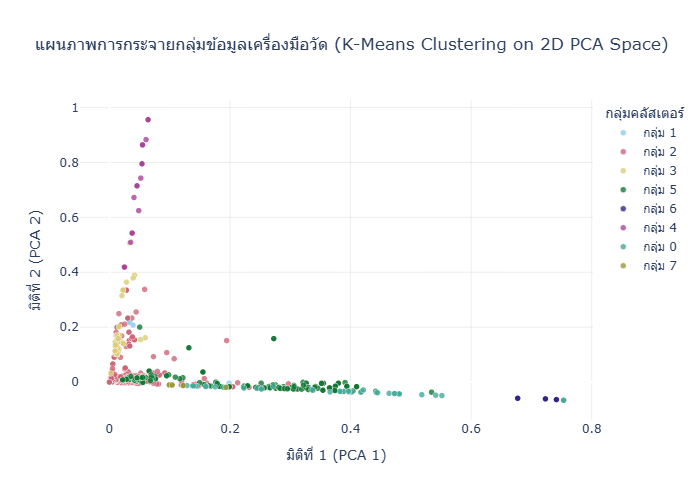

In [12]:
from sklearn.cluster import KMeans
import plotly.express as px

# 1. สร้างโมเดล K-Means เพื่อค้นหากลุ่มความสัมพันธ์ 8 กลุ่ม
kmeans = KMeans(n_clusters=8, random_state=42, n_init=10)

# 2. สั่งโมเดลเรียนรู้และระบุรหัสกลุ่มคลัสเตอร์ (0 ถึง 7)
kmeans.fit(X_all_pca)

# บันทึกรหัสกลุ่มที่ได้กลับไปยังตารางหลัก เพื่อนำไปใช้วาดแดชบอร์ด
df['Cluster_ID'] = kmeans.labels_
print("โมเดลจัดกลุ่มคลัสเตอร์ (Clustering) สำเร็จเสร็จสิ้น!")

# 3. พลอตกราฟ Scatter Plot 2 มิติเพื่อแสดงผลการแบ่งกลุ่มข้อมูลสิทธิบัตร/เครื่องมือวัด
df_km_viz = pd.DataFrame({
    'PCA Component 1': X_all_2d[:, 0],
    'PCA Component 2': X_all_2d[:, 1],
    'Cluster': ['กลุ่ม ' + str(c) for c in df['Cluster_ID']],
    'Description': df['รายละเอียดเครื่องมือ (Description)'].values,
    'Department': df['ฝ่ายงานจริง (Actual Department)'].values,
})

fig_km = px.scatter(
    df_km_viz,
    x='PCA Component 1',
    y='PCA Component 2',
    color='Cluster',
    hover_data=['Description', 'Department'],
    title='แผนภาพการกระจายกลุ่มข้อมูลเครื่องมือวัด (K-Means Clustering on 2D PCA Space)',
    color_discrete_sequence=px.colors.qualitative.Safe,
    labels={
        'PCA Component 1': 'มิติที่ 1 (PCA 1)',
        'PCA Component 2': 'มิติที่ 2 (PCA 2)'
    }
)
fig_km.update_traces(marker=dict(size=6, opacity=0.8, line=dict(width=0.5, color='white')))
fig_km.update_layout(
    legend_title='กลุ่มคลัสเตอร์',
    xaxis=dict(showgrid=True, gridcolor='rgba(200,200,200,0.3)'),
    yaxis=dict(showgrid=True, gridcolor='rgba(200,200,200,0.3)'),
    plot_bgcolor='white',
    height=500
)
fig_km.show()


--- 
## 7. ผลลัพธ์และการประเมินผลลัพธ์โมเดล (Results & Evaluation)

**วิธีทำความเข้าใจตัวชี้วัด:**
ในงานวิทยาศาสตร์ข้อมูล การใช้ Accuracy รวมอย่างเดียวอาจไม่เพียงพอ เราต้องดู **Classification Report** ประกอบด้วย:
*   **Precision:** ความแม่นยำในการทำนายของโมเดล (เช่น หากโมเดลบอกว่าเครื่องมือนี้เป็นของฝ่ายไฟฟ้า 10 ชิ้น แล้วเป็นของฝ่ายไฟฟ้าจริงๆ กี่ชิ้น)
*   **Recall:** ความสามารถในการกวาดข้อมูลมาได้ครบถ้วน (เช่น ในคลังมีงานของฝ่ายไฟฟ้าจริงๆ 10 ชิ้น โมเดลสามารถหาเจอและทำนายมาได้ครบ 10 ชิ้นหรือไม่)
*   **F1-Score:** ค่าเฉลี่ยแบบ Harmonic Mean ระหว่าง Precision และ Recall เพื่อดูเสถียรภาพโดยรวมของกลุ่มงานนั้นๆ

In [13]:
from sklearn.metrics import classification_report

# พิมพ์รายงานสถิติตัวชี้วัดในการทำนายฝ่ายงานอย่างละเอียด
print("รายงานจำแนกประสิทธิภาพรายฝ่ายงาน (Classification Report):\n")
print(classification_report(y_test, y_pred))

รายงานจำแนกประสิทธิภาพรายฝ่ายงาน (Classification Report):

                                                    precision    recall  f1-score   support

                            Acoustic and Vibration       1.00      0.65      0.79        17
                     Chemical Metrology Department       0.93      0.93      0.93        70
                  Dimensional Metrology Department       0.89      0.94      0.91        51
                   Electrical Metrology Department       0.89      0.93      0.91        54
Innovation and Measuring Devices Development Group       0.71      0.45      0.56        11
                   Mechanical Metrology Department       0.84      0.96      0.89        74
                         Medical Metrology Program       0.00      0.00      0.00         2
                  Thermometry Metrology Department       1.00      0.89      0.94        37

                                          accuracy                           0.90       316
                   

E:\DGA_2\venv\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
E:\DGA_2\venv\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
E:\DGA_2\venv\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


### 7.2 ภาพสรุปตัวชี้วัดโมเดล (Metrics Visualization)

- **Confusion Matrix** — แสดงว่าโมเดลทำนายผิดอย่างไรระหว่างฝ่ายงานใด
- **Precision / Recall / F1-Score Bar Chart** — เปรียบเทียบประสิทธิภาพรายฝ่ายงาน


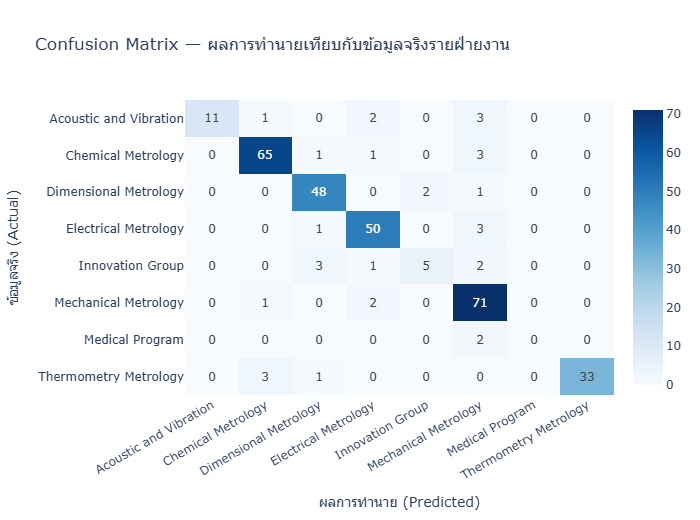

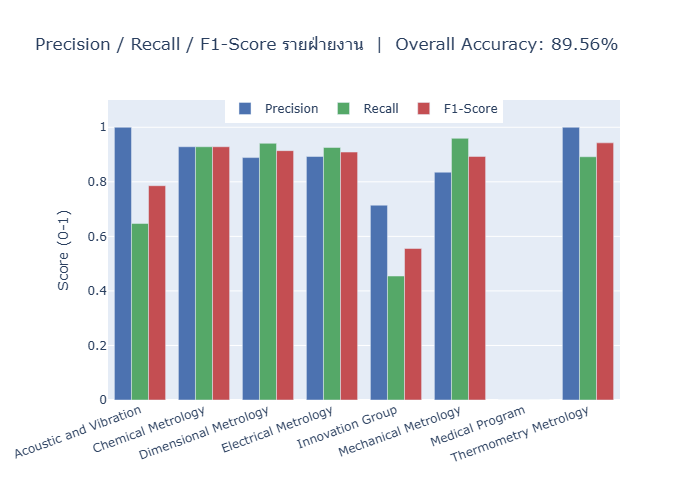

In [14]:
from sklearn.metrics import (confusion_matrix, precision_score,
                              recall_score, f1_score, accuracy_score)
import plotly.graph_objects as go

class_labels = sorted(df['ฝ่ายงานจริง (Actual Department)'].unique())
short_labels = [
    l.replace('Metrology Department', 'Metrology')
     .replace('Metrology Program', 'Program')
     .replace('Innovation and Measuring Devices Development Group', 'Innovation Group')
    for l in class_labels
]

# --- Confusion Matrix Heatmap ---
cm = confusion_matrix(y_test, y_pred, labels=class_labels)
fig_cm = go.Figure(data=go.Heatmap(
    z=cm.tolist(),
    x=short_labels,
    y=short_labels,
    colorscale='Blues',
    text=cm.tolist(),
    texttemplate='%{text}',
    textfont={'size': 12},
    showscale=True
))
fig_cm.update_layout(
    title='Confusion Matrix — ผลการทำนายเทียบกับข้อมูลจริงรายฝ่ายงาน',
    xaxis_title='ผลการทำนาย (Predicted)',
    yaxis_title='ข้อมูลจริง (Actual)',
    xaxis_tickangle=-30,
    yaxis_autorange='reversed',
    height=520
)
fig_cm.show()

# --- Precision / Recall / F1 Bar Chart ---
acc       = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, labels=class_labels, average=None, zero_division=0)
recall    = recall_score(y_test, y_pred, labels=class_labels, average=None, zero_division=0)
f1        = f1_score(y_test, y_pred, labels=class_labels, average=None, zero_division=0)

fig_metrics = go.Figure()
fig_metrics.add_trace(go.Bar(name='Precision', x=short_labels, y=precision.tolist(),
                             marker_color='#4C72B0'))
fig_metrics.add_trace(go.Bar(name='Recall',    x=short_labels, y=recall.tolist(),
                             marker_color='#55A868'))
fig_metrics.add_trace(go.Bar(name='F1-Score',  x=short_labels, y=f1.tolist(),
                             marker_color='#C44E52'))
fig_metrics.update_layout(
    barmode='group',
    title=f'Precision / Recall / F1-Score รายฝ่ายงาน  |  Overall Accuracy: {acc:.2%}',
    yaxis=dict(title='Score (0-1)', range=[0, 1.1]),
    xaxis_tickangle=-20,
    height=480,
    legend=dict(orientation='h', y=1.02, x=0.5, xanchor='center')
)
fig_metrics.show()


In [15]:
# สกัดคำสำคัญเด่น (Top Words) จากแต่ละกลุ่มคลัสเตอร์ K-Means
# K-Means ถูก fit บน PCA space → ใช้ svd_ml.inverse_transform() project centroid กลับ TF-IDF space
terms = vectorizer.get_feature_names_out()
centroids_tfidf = svd_ml.inverse_transform(kmeans.cluster_centers_)  # (8, 500)
order_centroids = centroids_tfidf.argsort()[:, ::-1]

cluster_labels_map = {}
print('การตีความลักษณะกลุ่มเครื่องมือตาม K-Means:')
for i in range(8):
    top_words = [terms[ind] for ind in order_centroids[i, :5]]
    keywords_str = ', '.join(top_words)
    cluster_labels_map[i] = f'กลุ่ม {i}: ({keywords_str})'
    print(f'  - กลุ่มที่ {i}: คีย์เวิร์ดหลักคือ: {keywords_str}')

df['Cluster_Keywords'] = df['Cluster_ID'].map(cluster_labels_map)


การตีความลักษณะกลุ่มเครื่องมือตาม K-Means:
  - กลุ่มที่ 0: คีย์เวิร์ดหลักคือ: solution, standard, sucrose, brix, dna
  - กลุ่มที่ 1: คีย์เวิร์ดหลักคือ: laser, frequency, measurement, sensitivity, additional
  - กลุ่มที่ 2: คีย์เวิร์ดหลักคือ: meter, nitrogen, power, voltage, phase
  - กลุ่มที่ 3: คีย์เวิร์ดหลักคือ: gauge, block, rectangular, material, ring
  - กลุ่มที่ 4: คีย์เวิร์ดหลักคือ: pressure, instruments, gas, measuring, pe
  - กลุ่มที่ 5: คีย์เวิร์ดหลักคือ: standard, calibration, torque, machine, devices
  - กลุ่มที่ 6: คีย์เวิร์ดหลักคือ: mass, standard, set, balance, inter
  - กลุ่มที่ 7: คีย์เวิร์ดหลักคือ: pesticide, mix, set, organophosphate, organochlorine


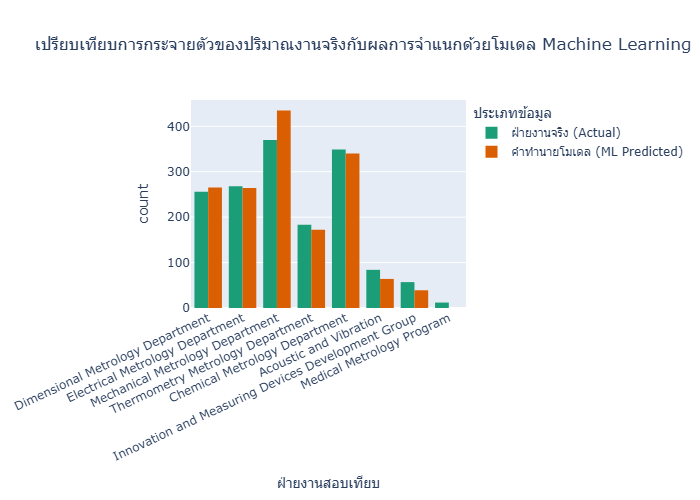

In [16]:
# 7.3 พลอตกราฟเปรียบเทียบข้อมูลจริงกับข้อมูลที่โมเดลคัดแยก
# เพื่อทดสอบดูความเพี้ยนหรือจุดเบี่ยงเบนในระดับโครงสร้างรายฝ่ายงาน
all_predictions = classifier.predict(X_all_pca)

df_compare = pd.DataFrame({
    'ประเภทข้อมูล': ['ฝ่ายงานจริง (Actual)'] * len(df) + ['คำทำนายโมเดล (ML Predicted)'] * len(df),
    'ฝ่ายงานสอบเทียบ': list(df['ฝ่ายงานจริง (Actual Department)']) + list(all_predictions)
})

fig_compare = px.histogram(
    df_compare, 
    x='ฝ่ายงานสอบเทียบ', 
    color='ประเภทข้อมูล', 
    barmode='group',
    title='เปรียบเทียบการกระจายตัวของปริมาณงานจริงกับผลการจำแนกด้วยโมเดล Machine Learning',
    labels={'count': 'จำนวนเครื่องมือ (รายการ)', 'ฝ่ายงานสอบเทียบ': 'ฝ่ายงานสอบเทียบ'},
    color_discrete_sequence=px.colors.qualitative.Dark2
)
fig_compare.update_layout(xaxis_tickangle=-25, height=500)
fig_compare.show()

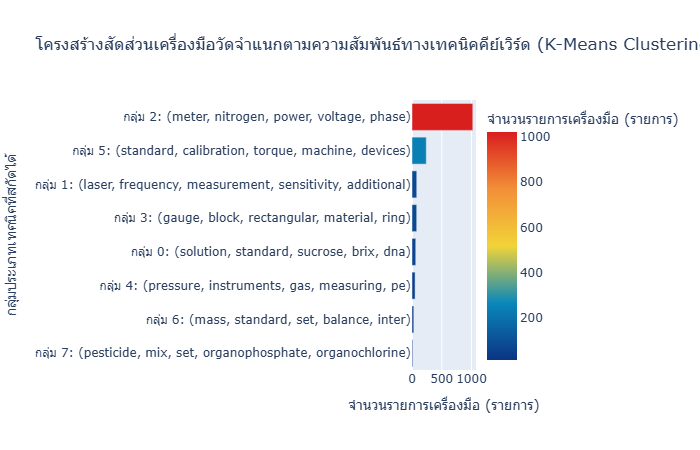


--- สิ้นสุดสมุดบันทึกโครงการ Data Science สถาบันมาตรวิทยาอย่างเป็นทางการ ---


In [17]:
# 7.4 พลอตกราฟผลการทำโมเดลแบ่งส่วนตลาดเครื่องมือสอบเทียบ (Market Segmentation by K-Means Clusters)
cluster_counts = df['Cluster_ID'].value_counts().reset_index()
cluster_counts.columns = ['Cluster_ID', 'Count']
cluster_counts['Cluster_Description'] = cluster_counts['Cluster_ID'].map(cluster_labels_map)

fig_clusters = px.bar(
    cluster_counts,
    x='Count',
    y='Cluster_Description',
    orientation='h',
    title='โครงสร้างสัดส่วนเครื่องมือวัดจำแนกตามความสัมพันธ์ทางเทคนิคคีย์เวิร์ด (K-Means Clustering)',
    labels={'Count': 'จำนวนรายการเครื่องมือ (รายการ)', 'Cluster_Description': 'กลุ่มประเภทเทคนิคที่สกัดได้'},
    color='Count',
    color_continuous_scale='Portland'
)
fig_clusters.update_layout(yaxis={'categoryorder':'total ascending'}, height=450)
fig_clusters.show()
print("\n--- สิ้นสุดสมุดบันทึกโครงการ Data Science สถาบันมาตรวิทยาอย่างเป็นทางการ ---")

### 7.5 Scatter Plot — กลุ่มคลัสเตอร์ K-Means ในพื้นที่ 2 มิติ (PCA Projection)

**แต่ละจุด** = เครื่องมือสอบเทียบ 1 ชิ้น  
**สี** = กลุ่มคลัสเตอร์ที่โมเดล K-Means กำหนด  
**แกน XY** = 2 มิติแรกจาก PCA ที่สรุป pattern หลักของข้อมูล TF-IDF


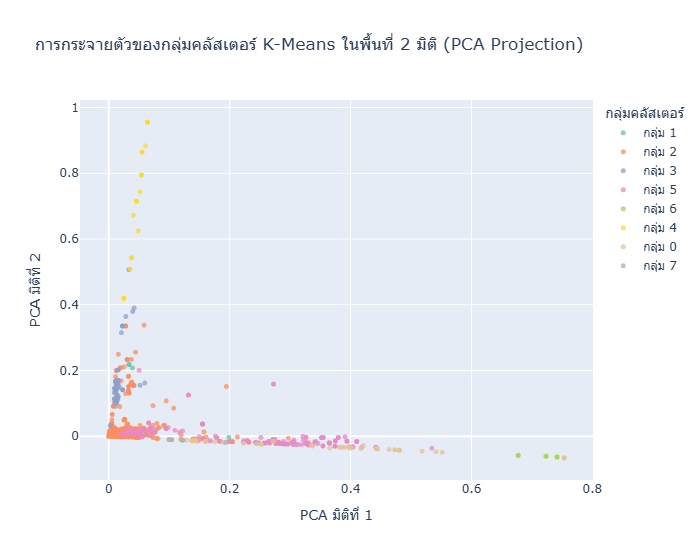


--- สิ้นสุดสมุดบันทึกโครงการ Data Science สถาบันมาตรวิทยาอย่างเป็นทางการ ---


In [18]:
# 7.5 Scatter Plot: K-Means Clusters in 2D PCA Space
df_viz = pd.DataFrame({
    'PCA Component 1': X_all_2d[:, 0],
    'PCA Component 2': X_all_2d[:, 1],
    'Cluster': ['กลุ่ม ' + str(c) for c in df['Cluster_ID']],
    'Description': df['รายละเอียดเครื่องมือ (Description)'].values,
    'Department': df['ฝ่ายงานจริง (Actual Department)'].values,
})

fig_scatter = px.scatter(
    df_viz,
    x='PCA Component 1',
    y='PCA Component 2',
    color='Cluster',
    hover_data=['Description', 'Department'],
    title='การกระจายตัวของกลุ่มคลัสเตอร์ K-Means ในพื้นที่ 2 มิติ (PCA Projection)',
    color_discrete_sequence=px.colors.qualitative.Set2,
    labels={
        'PCA Component 1': 'PCA มิติที่ 1',
        'PCA Component 2': 'PCA มิติที่ 2'
    }
)
fig_scatter.update_traces(marker=dict(size=5, opacity=0.75))
fig_scatter.update_layout(height=560, legend_title='กลุ่มคลัสเตอร์')
fig_scatter.show()
print('\n--- สิ้นสุดสมุดบันทึกโครงการ Data Science สถาบันมาตรวิทยาอย่างเป็นทางการ ---')


1. ปัญหาคืออะไร? (The Pain Points)
ความซับซ้อนของข้อมูลทางเทคนิค: รายชื่อและรายละเอียดของเครื่องมือวัด (Description) มักจะเขียนเป็นคำศัพท์เฉพาะทางวิศวกรรมที่หลากหลายและไม่เป็นมาตรฐานเดียวกัน (เช่น บางอันเขียน Laser, บางอันเขียน He-Ne, บางอันเขียน Multimeter)
คอขวดจากการคัดแยกด้วยมนุษย์ (Human Bottleneck): เมื่อลูกค้าส่งเครื่องมือมาสอบเทียบ เจ้าหน้าที่ต้องอ่านรายละเอียดเทคนิคแล้วเลือกส่งต่อไปยังฝ่ายงานที่ถูกต้อง (เช่น ฝ่ายมิติ, ฝ่ายไฟฟ้า, ฝ่ายอุณหภูมิ) ซึ่งต้องใช้ผู้เชี่ยวชาญ และเสี่ยงต่อความผิดพลาดหากพนักงานใหม่ทำงาน
การตั้งราคาและวางแผนทรัพยากร: ด้วยเครื่องมือที่มีมากกว่า 1,500 รายการ เป็นเรื่องยากที่ผู้บริหารจะมองเห็นภาพรวมว่าบริการกลุ่มไหนมีราคาเฉลี่ยสูง หรือเทคโนโลยีกลุ่มไหนที่ลูกค้าส่งมามากที่สุดเพื่อที่จะได้เข้าไปลงทุนซื้อเครื่องมือมาตรฐานราคาแพงมาไว้บริการ
2. เราทำ Data Science ไปเพื่ออะไร? (The Solutions)
💡 เพื่อลดภาระงานด้วยระบบอัตโนมัติ (Automated Routing)
ทำไปทำไม: จากข้อ 6.1 ที่เราทำ Classification (Logistic Regression)
ผลลัพธ์: ปัจจุบันเราได้โมเดลที่สามารถอ่านชื่อเครื่องมือ (เช่น "Iodine Stabilized He-Ne laser") แล้วตอบได้ทันทีด้วยความแม่นยำสูงถึง ~90% ว่าต้องส่งไปให้ "ฝ่ายมาตรวิทยามิติ"
เป้าหมายจริง: นำไปพัฒนาเป็นระบบคัดแยกคำขอรับบริการอัตโนมัติ (Auto-ticket Routing) เมื่อลูกค้าคีย์ข้อมูลในระบบ โมเดลจะส่งงานตรงไปยังฝ่ายนั้นทันทีโดยไม่ต้องรอคนคัดแยก
💡 เพื่อจัดกลุ่มการบริการและเทคโนโลยี (Service Segmentation)
ทำไปทำไม: จากข้อ 6.2 ที่เราทำ Clustering (K-Means)
ผลลัพธ์: โมเดลช่วยจัดกลุ่มเครื่องมือ 1,579 รายการออกเป็น 8 กลุ่มตามความเกี่ยวโยงทางเทคโนโลยี (เช่น กลุ่มแก๊สเคมี, กลุ่มกำลังไฟฟ้า, กลุ่มบล็อกเกจ) โดยที่เราไม่ต้องตั้งกฎเอง
เป้าหมายจริง:
การวิเคราะห์ตลาด (Market Analysis): ทำให้เห็นว่ากลุ่มเทคโนโลยีใดถูกส่งมามากที่สุด เพื่อวางแผนจัดซื้อเครื่องมือมาตรฐานและฝึกอบรมบุคคลากรล่วงหน้า
การปรับปรุงระบบฐานข้อมูล: เพื่อตรวจสอบว่าคำค้นหา (Keywords) หรือรหัสบริการมีการกำหนดอย่างเป็นระบบหรือไม่
💡 เพื่อตรวจสอบความผิดปกติของโครงสร้างราคา (Pricing Integrity)
ทำไปทำไม: จากการทำ EDA (Box Plot ของราคาค่าบริการ)
ผลลัพธ์: เพื่อหา Outliers (ค่าที่สูงหรือต่ำผิดปกติ) ในแต่ละฝ่ายงาน
เป้าหมายจริง: ช่วยระบุเครื่องมือที่อาจมีการกรอกราคาผิดพลาดในระบบ หรือชี้เป้าเครื่องมือพิเศษที่มีมูลค่าการสอบเทียบสูงมาก เพื่อให้ฝ่ายบัญชีและการตลาดให้ความสำคัญเป็นพิเศษ
|